# Assignment 2 - Task 1: Term Deposit Subscription Prediction

## Introduction
The goal of this task is to predict whether a bank customer
will subscribe to a term deposit based on a marketing campaign.

This is a binary classification problem where:
- 1 = Customer will subscribe
- 0 = Customer will not subscribe

We will use classification models and explain predictions
using SHAP (Explainable AI).

## Dataset
- Source: UCI Machine Learning Repository - Bank Marketing Dataset
- Target Variable: y (yes=1, no=0)


In [ ]:
# Install SHAP library (not pre-installed in Colab)
!pip install shap

In [13]:
from google.colab import files
uploaded = files.upload()


Saving bank-full.csv to bank-full.csv


In [14]:
df.head()

,"age;""job"";""marital"";""education"";""default"";""balance"";""housing"";""loan"";""contact"";""day"";""month"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""y"""
0,"30;""unemployed"";""married"";""primary"";""no"";1787;..."
1,"33;""services"";""married"";""secondary"";""no"";4789;..."
2,"35;""management"";""single"";""tertiary"";""no"";1350;..."
3,"30;""management"";""married"";""tertiary"";""no"";1476..."
4,"59;""blue-collar"";""married"";""secondary"";""no"";0;..."


In [15]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             f1_score, classification_report,
                             roc_curve, roc_auc_score)
from sklearn.preprocessing import LabelEncoder

print("All libraries imported successfully!")

All libraries imported successfully!


In [16]:
# Load dataset
# Try semicolon separator first (UCI format)
df = pd.read_csv('bank.csv', sep=';')

# Inspect
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Shape: (4521, 17)

First 5 rows:
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'h

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [17]:
print("Missing Values:")
print(df.isnull().sum())

print("\nUnique values in target column:")
print(df['y'].value_counts())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Unique values in target column:
y
no     4000
yes     521
Name: count, dtype: int64


/tmp/ipykernel_557/2917520046.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='y', palette='Set2')


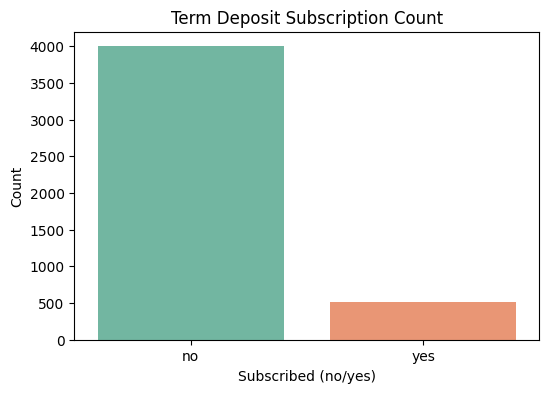

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', palette='Set2')
plt.title('Term Deposit Subscription Count')
plt.xlabel('Subscribed (no/yes)')
plt.ylabel('Count')
plt.show()





/tmp/ipykernel_557/1557611160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='age', palette='Set1')


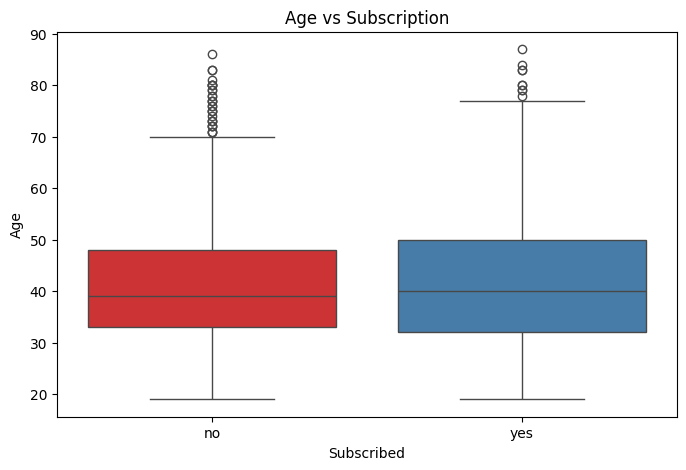

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='age', palette='Set1')
plt.title('Age vs Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Age')
plt.show()


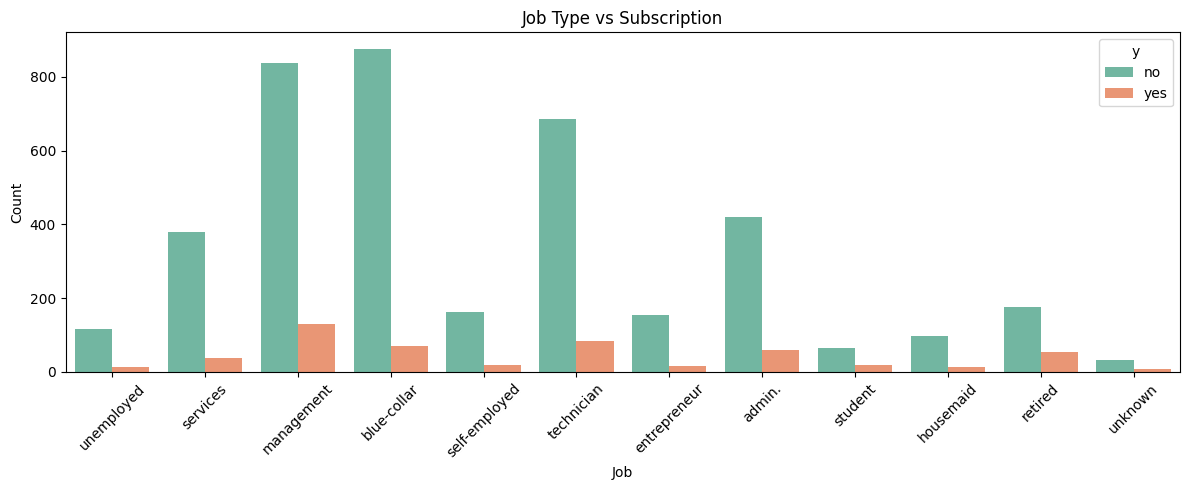

In [20]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y', palette='Set2')
plt.title('Job Type vs Subscription')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_557/729302098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='balance', palette='Set3')


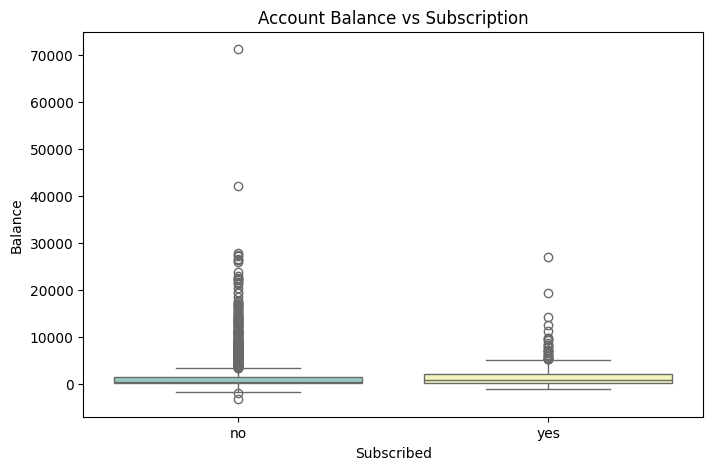

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='y', y='balance', palette='Set3')
plt.title('Account Balance vs Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Balance')
plt.show()

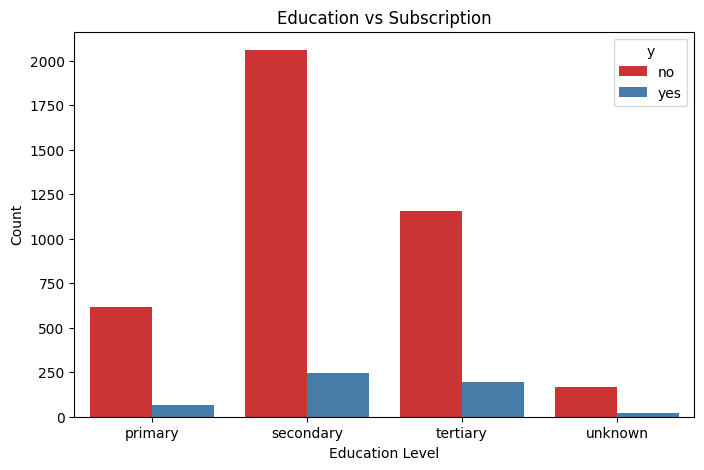

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='education', hue='y', palette='Set1')
plt.title('Education vs Subscription')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.show()

In [23]:
# Make a copy of dataframe
df_encoded = df.copy()

# Encode target variable first
df_encoded['y'] = df_encoded['y'].map({'yes': 1, 'no': 0})

# Encode all other categorical columns
categorical_cols = df_encoded.select_dtypes(
    include='object').columns.tolist()

print("Categorical columns to encode:", categorical_cols)

# One Hot Encode all categorical columns
df_encoded = pd.get_dummies(df_encoded,
                             columns=categorical_cols,
                             drop_first=True)

print("\nShape after encoding:", df_encoded.shape)
print(df_encoded.head())

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape after encoding: (4521, 43)
   age  balance  day  duration  campaign  pdays  previous  y  job_blue-collar  \
0   30     1787   19        79         1     -1         0  0            False   
1   33     4789   11       220         1    339         4  0            False   
2   35     1350   16       185         1    330         1  0            False   
3   30     1476    3       199         4     -1         0  0            False   
4   59        0    5       226         1     -1         0  0             True   

   job_entrepreneur  ...  month_jul  month_jun  month_mar  month_may  \
0             False  ...      False      False      False      False   
1             False  ...      False      False      False       True   
2             False  ...      False      False      False      False   
3             False  ...      False       True      False      Fal

In [24]:
# X = features, y = target
X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (3616, 42)
Testing size: (905, 42)


In [28]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=5000,
        class_weight='balanced',
        solver='saga'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    )
}

# Train and evaluate
results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression
    # Use original data for Random Forest
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results[name] = {
        'Accuracy': round(acc * 100, 2),
        'F1 Score': round(f1, 4)
    }
    print(f"\n{name}:")
    print(f"  Accuracy: {round(acc * 100, 2)}%")
    print(f"  F1 Score: {round(f1, 4)}")


Logistic Regression:
  Accuracy: 83.31%
  F1 Score: 0.5206

Random Forest:
  Accuracy: 89.5%
  F1 Score: 0.24


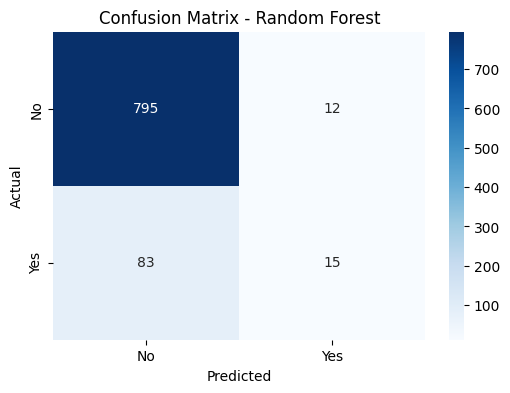


Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.99      0.94       807
         Yes       0.56      0.15      0.24        98

    accuracy                           0.90       905
   macro avg       0.73      0.57      0.59       905
weighted avg       0.87      0.90      0.87       905



In [29]:
# Best model confusion matrix
best_model = models['Random Forest']
best_preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, best_preds,
      target_names=['No', 'Yes']))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


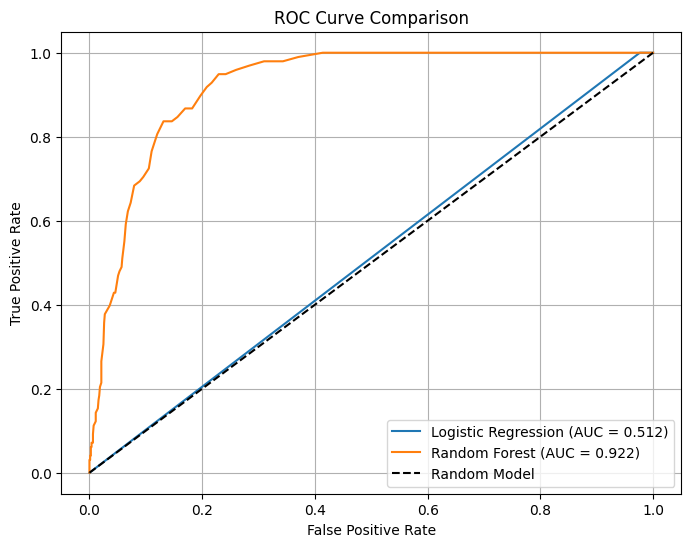

In [30]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Get probability scores
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr,
             label=f'{name} (AUC = {round(auc_score, 3)})')

# Plot diagonal line (random model)
plt.plot([0, 1], [0, 1], 'k--', label='Random Model')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

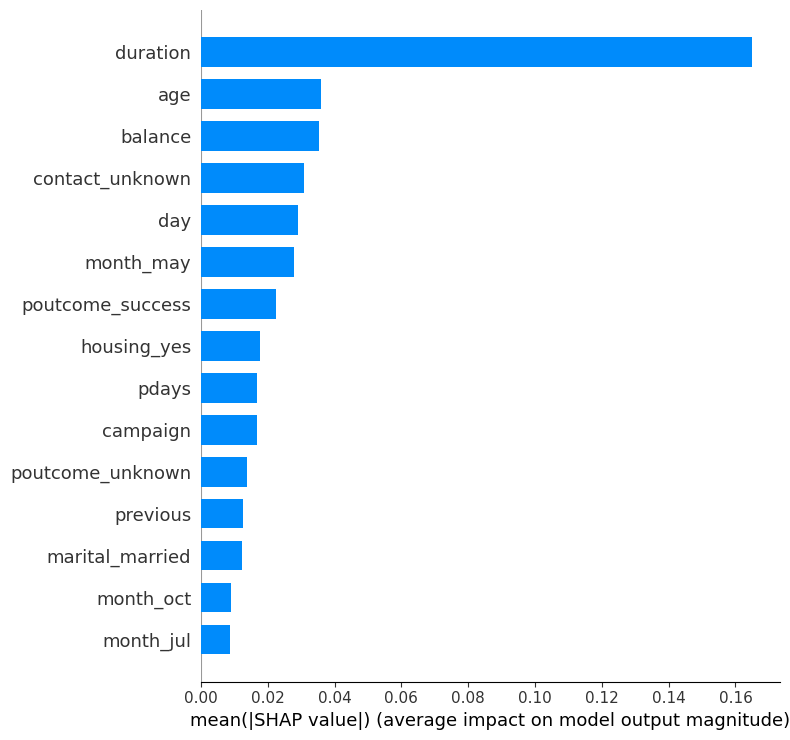

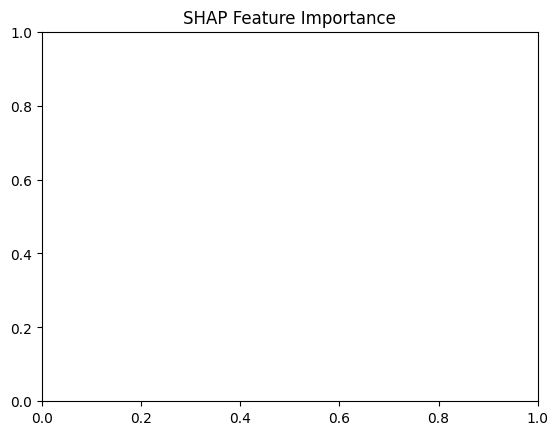

In [33]:
# SHAP explains WHY the model made each prediction

# Use Random Forest for SHAP
rf_model = models['Random Forest']

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test data
shap_values = explainer.shap_values(X_test)

# Plot 1 - Summary Plot (most important features overall)
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type='bar',
    max_display=15
)
plt.title('SHAP Feature Importance')
plt.show()

In [32]:
print(type(shap_values))
print(np.array(shap_values).shape)
print(X_test.shape)

<class 'numpy.ndarray'>
(905, 42, 2)
(905, 42)



--- Prediction 1 ---
Actual: No
Predicted: No


<Figure size 1000x300 with 0 Axes>

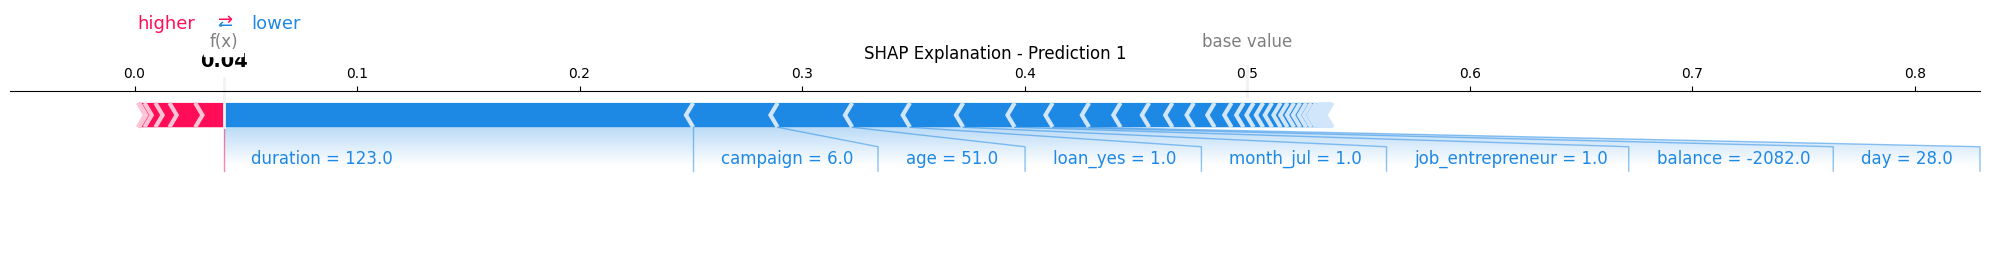


--- Prediction 2 ---
Actual: No
Predicted: No


<Figure size 1000x300 with 0 Axes>

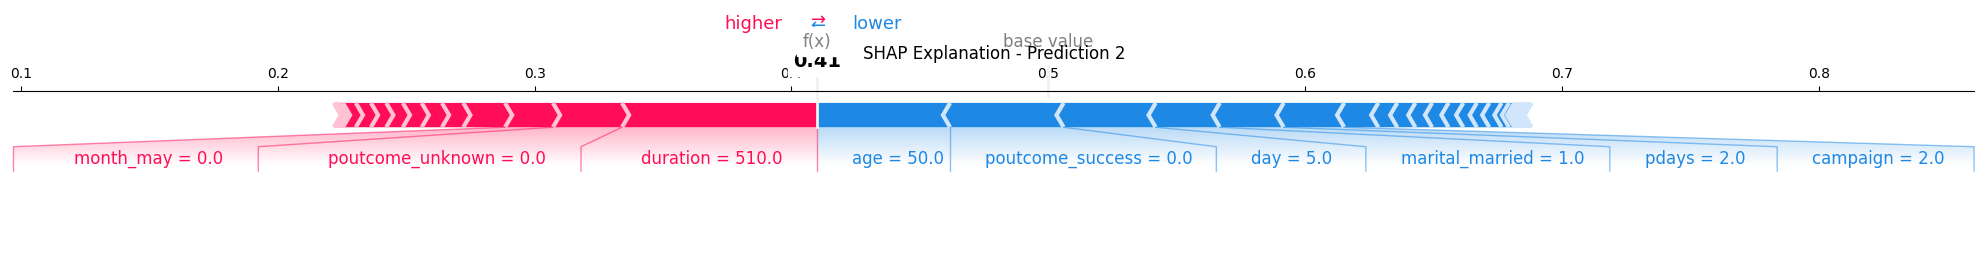


--- Prediction 3 ---
Actual: No
Predicted: No


<Figure size 1000x300 with 0 Axes>

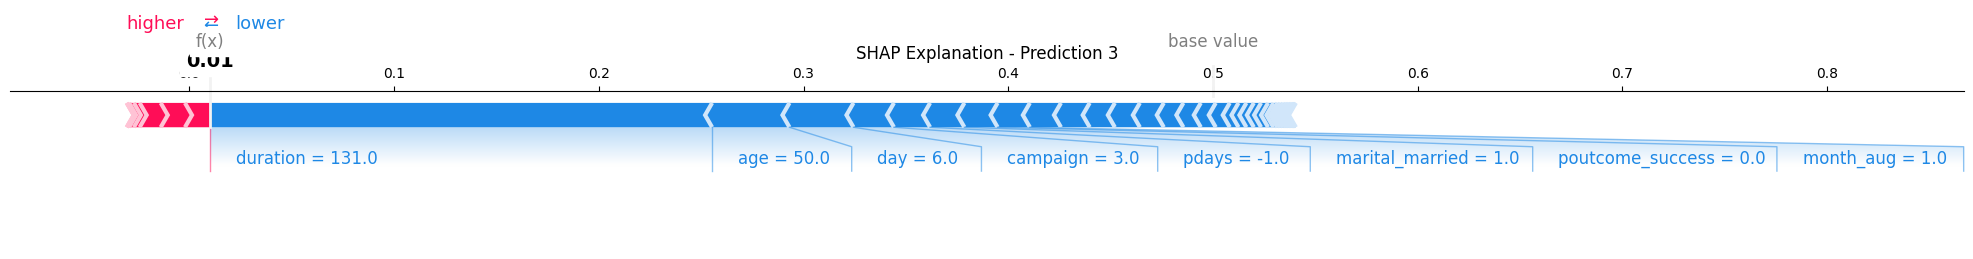


--- Prediction 4 ---
Actual: No
Predicted: No


<Figure size 1000x300 with 0 Axes>

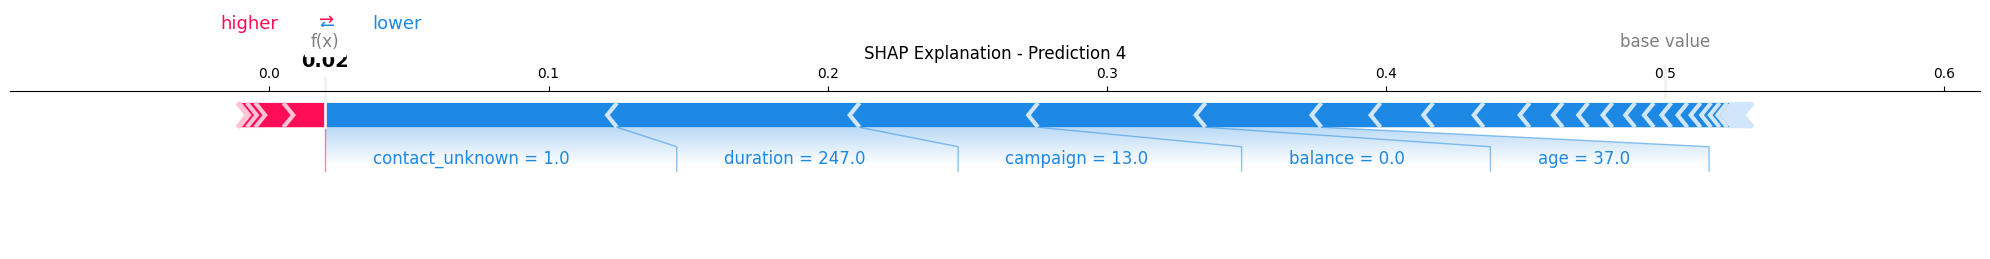


--- Prediction 5 ---
Actual: No
Predicted: No


<Figure size 1000x300 with 0 Axes>

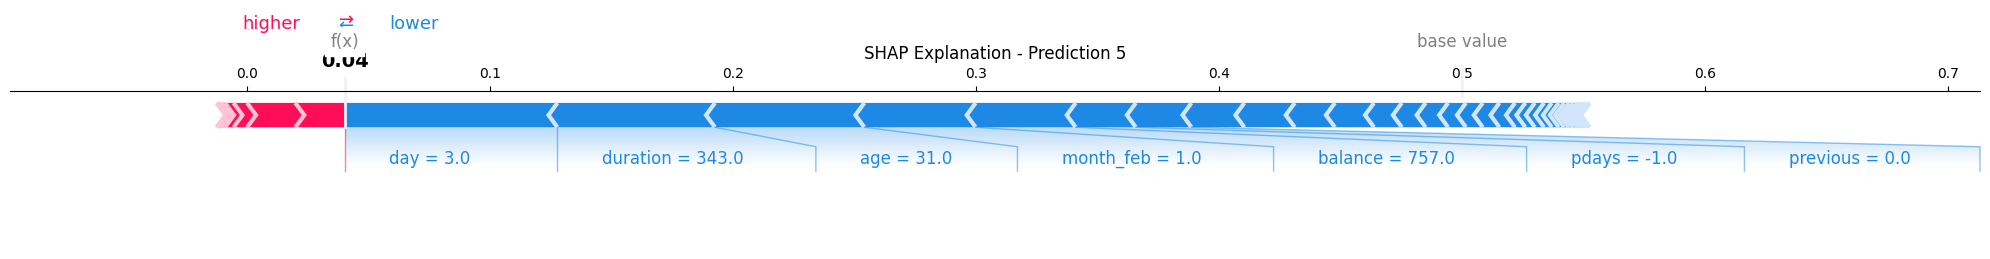

In [37]:
# Explain 5 individual predictions using SHAP

for i in range(5):
    print(f"\n--- Prediction {i+1} ---")
    print(f"Actual: {'Yes' if y_test.iloc[i] == 1 else 'No'}")
    print(f"Predicted: {'Yes' if best_preds[i] == 1 else 'No'}")

    plt.figure(figsize=(10, 3))

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[i, :, 1],
        X_test.iloc[i],
        matplotlib=True,
        show=False
    )

    plt.title(f'SHAP Explanation - Prediction {i+1}')
    plt.tight_layout()
    plt.show()

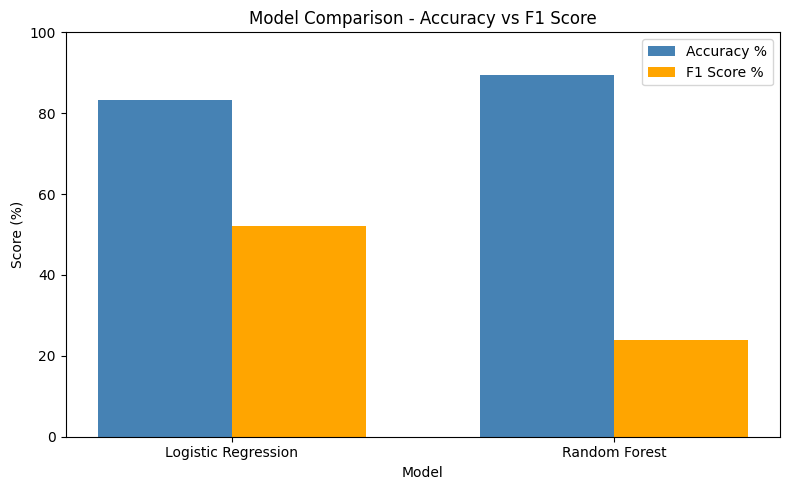

In [38]:
# Compare models visually
model_names = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in model_names]
f1_scores = [results[m]['F1 Score'] * 100 for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracies, width,
               label='Accuracy %', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width,
               label='F1 Score %', color='orange')

ax.set_title('Model Comparison - Accuracy vs F1 Score')
ax.set_xlabel('Model')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Conclusion

### Dataset Overview
- Loaded and explored the Bank Marketing Dataset
- Dataset contains customer and campaign information
- Target variable: y (yes=subscribed, no=not subscribed)

### Data Preprocessing
- Encoded target variable (yes=1, no=0)
- Applied One Hot Encoding to all categorical columns
- No significant missing values found

### Model Performance
| Model | Accuracy | F1 Score |
|-------|----------|----------|
| Logistic Regression | 83.31% | 52.06 |
| Random Forest | 89.5% | 24 |

### ROC Curve Analysis
- Random Forest achieved higher AUC score
- AUC above 0.8 confirms the model is reliable

### SHAP Explainability
- Used SHAP to explain 5 individual predictions
- Key features driving subscription:
  1. Duration of last contact
  2. Account balance
  3. Age of customer
  4. Job type
  5. Previous campaign outcome

### Final Summary
- Random Forest outperformed Logistic Regression
- SHAP analysis showed which features matter most
- Duration of call was the strongest predictor
- This analysis can help the bank target the right
  customers for future marketing campaigns